# MinoLingo — Dropout Prediction & Course Recommendation

**Business objective:** *Réduire le taux d'abandon des cours.*  
**Data science objective:** *Utiliser le Machine Learning pour recommander un cours mieux adapté.*

**Models:** Random Forest vs XGBoost — with hyperparameter tuning (`GridSearchCV`).  
**Tasks:**
1. Binary classification — `dropped_out` (will the child abandon the course?)
2. Multi-class classification — `best_course_category` (which course should we recommend?)

**Notebook plan:**
1. Load dirty CSV
2. Inspect & profile
3. Clean (nulls, duplicates, outliers, casing, type coercion)
4. EDA + visualizations
5. Feature engineering & encoding
6. Train RF & XGB with hyperparameter tuning
7. Live comparison
8. Persist models for the FastAPI backend

## 1. Imports & setup

In [3]:
import json
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = Path('../data/courses_dataset.csv')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

## 2. Load the dirty dataset

In [4]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (12180, 23)


,user_id,age,english_level,daily_minutes,sessions_per_week,avg_session_duration,streak_days,time_since_last_login,quiz_attempts,quiz_avg_score,...,story_quiz_attempts,certification_earned,course_category,course_difficulty,instructor_rating,device_type,subscription_type,parent_involvement_score,dropped_out,best_course_category
0,3781,5,A1,10.2,2.9,25.0,2,5,6,47.5,...,0,0,Listening,3,4.56,mobile,free,2.0,0,Writing
1,6340,9,A2,19.2,4.8,28.0,8,9,12,62.6,...,6,0,Speaking,3,4.46,tablet,free,4.0,0,Reading
2,10472,10,B1,38.4,5.1,53.0,17,2,20,78.5,...,10,0,Reading,1,3.87,mobile,free,10.0,0,Writing
3,10109,9,B1,0.0,0.0,2.0,0,15,0,29.9,...,0,0,Speaking,5,3.98,desktop,family,6.0,1,Reading
4,632,7,unknown,25.5,5.0,35.9,6,7,13,57.9,...,7,0,Writing,5,3.89,mobile,free,6.0,0,Listening


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12180 entries, 0 to 12179
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   12180 non-null  int64  
 1   age                       12180 non-null  int64  
 2   english_level             12180 non-null  object 
 3   daily_minutes             11838 non-null  float64
 4   sessions_per_week         12180 non-null  float64
 5   avg_session_duration      12180 non-null  float64
 6   streak_days               12180 non-null  int64  
 7   time_since_last_login     12180 non-null  int64  
 8   quiz_attempts             12180 non-null  int64  
 9   quiz_avg_score            11803 non-null  float64
 10  videos_watched_pct        11800 non-null  float64
 11  practice_items_completed  12180 non-null  int64  
 12  writing_submissions       12180 non-null  int64  
 13  story_quiz_attempts       12180 non-null  int64  
 14  certif

In [6]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,12180.0,NaN,NaN,NaN,5996.612151,3463.48837,1.0,2999.75,5989.5,8997.25,12000.0
age,12180.0,NaN,NaN,NaN,9.292529,28.462612,5.0,6.0,8.0,10.0,999.0
english_level,12180,5,A1,4743,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_minutes,11838.0,NaN,NaN,NaN,15.056243,9.749249,-50.0,7.8,14.7,21.5,54.3
sessions_per_week,12180.0,NaN,NaN,NaN,3.026847,1.884782,0.0,1.6,3.0,4.3,10.7
avg_session_duration,12180.0,NaN,NaN,NaN,30.302718,15.829282,2.0,20.5,30.9,40.0,90.0
streak_days,12180.0,NaN,NaN,NaN,5.1133,4.581488,0.0,1.0,4.0,8.0,26.0
time_since_last_login,12180.0,NaN,NaN,NaN,6.638998,3.845908,0.0,4.0,7.0,9.0,21.0
quiz_attempts,12180.0,NaN,NaN,NaN,9.642118,6.141976,0.0,5.0,9.0,14.0,32.0
quiz_avg_score,11803.0,NaN,NaN,NaN,59.688079,16.159016,-10.0,49.0,59.7,70.7,100.0


## 3. Data cleaning

We address: missing values, sentinel strings (`'unknown'`, `'N/A'`, `''`, `'n/a'`), duplicates, outliers, inconsistent casing, and mixed types.

In [7]:
df = df_raw.copy()

# 3.1 Replace string-style missing markers with NaN
MISSING_TOKENS = ['unknown', 'N/A', 'n/a', '', 'NA', 'null', 'None']
df = df.replace(MISSING_TOKENS, np.nan)

# 3.2 Force numeric columns to numeric dtype
numeric_cols = [
    'age', 'daily_minutes', 'sessions_per_week', 'avg_session_duration',
    'streak_days', 'time_since_last_login', 'quiz_attempts', 'quiz_avg_score',
    'videos_watched_pct', 'practice_items_completed', 'writing_submissions',
    'story_quiz_attempts', 'certification_earned', 'course_difficulty',
    'instructor_rating', 'parent_involvement_score', 'dropped_out',
]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# 3.3 Normalize casing for categorical columns
for c in ['course_category', 'device_type', 'subscription_type', 'english_level', 'best_course_category']:
    df[c] = df[c].astype(str).str.strip().str.lower().replace('nan', np.nan)

# Re-capitalize course categories for readability
df['course_category'] = df['course_category'].str.capitalize()
df['best_course_category'] = df['best_course_category'].str.capitalize()
df['english_level'] = df['english_level'].str.upper()

print('Missing values per column:')
print(df.isna().sum().sort_values(ascending=False).head(15))

Missing values per column:
instructor_rating           488
videos_watched_pct          380
quiz_avg_score              377
parent_involvement_score    358
daily_minutes               342
english_level               256
device_type                 251
subscription_type           159
streak_days                   0
sessions_per_week             0
age                           0
user_id                       0
avg_session_duration          0
quiz_attempts                 0
time_since_last_login         0
dtype: int64


In [8]:
# 3.4 Drop duplicates (ignore user_id when comparing)
before = len(df)
df = df.drop_duplicates(subset=df.columns.difference(['user_id']))
print(f'Removed {before - len(df)} duplicate rows. New shape: {df.shape}')

Removed 175 duplicate rows. New shape: (12005, 23)


In [9]:
# 3.5 Handle outliers — clip to plausible ranges
df.loc[(df['age'] < 4) | (df['age'] > 14), 'age'] = np.nan
df.loc[df['daily_minutes'] < 0, 'daily_minutes'] = np.nan
df.loc[df['videos_watched_pct'] > 100, 'videos_watched_pct'] = 100
df.loc[df['videos_watched_pct'] < 0, 'videos_watched_pct'] = 0
df.loc[df['quiz_avg_score'] < 0, 'quiz_avg_score'] = np.nan
df.loc[df['quiz_avg_score'] > 100, 'quiz_avg_score'] = 100

# 3.6 Impute missing values
for c in numeric_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

for c in ['english_level', 'device_type', 'subscription_type']:
    df[c] = df[c].fillna(df[c].mode()[0])

print(f'Missing values remaining: {df.isna().sum().sum()}')
print(f'Final shape: {df.shape}')

Missing values remaining: 0
Final shape: (12005, 23)


In [10]:
# Save the cleaned dataset for later use
df.to_csv('../data/courses_dataset_clean.csv', index=False)
df.head()

,user_id,age,english_level,daily_minutes,sessions_per_week,avg_session_duration,streak_days,time_since_last_login,quiz_attempts,quiz_avg_score,...,story_quiz_attempts,certification_earned,course_category,course_difficulty,instructor_rating,device_type,subscription_type,parent_involvement_score,dropped_out,best_course_category
0,3781,5.0,A1,10.2,2.9,25.0,2,5,6,47.5,...,0,0,Listening,3,4.56,mobile,free,2.0,0,Writing
1,6340,9.0,A2,19.2,4.8,28.0,8,9,12,62.6,...,6,0,Speaking,3,4.46,tablet,free,4.0,0,Reading
2,10472,10.0,B1,38.4,5.1,53.0,17,2,20,78.5,...,10,0,Reading,1,3.87,mobile,free,10.0,0,Writing
3,10109,9.0,B1,0.0,0.0,2.0,0,15,0,29.9,...,0,0,Speaking,5,3.98,desktop,family,6.0,1,Reading
4,632,7.0,A1,25.5,5.0,35.9,6,7,13,57.9,...,7,0,Writing,5,3.89,mobile,free,6.0,0,Listening


## 4. EDA & visualizations

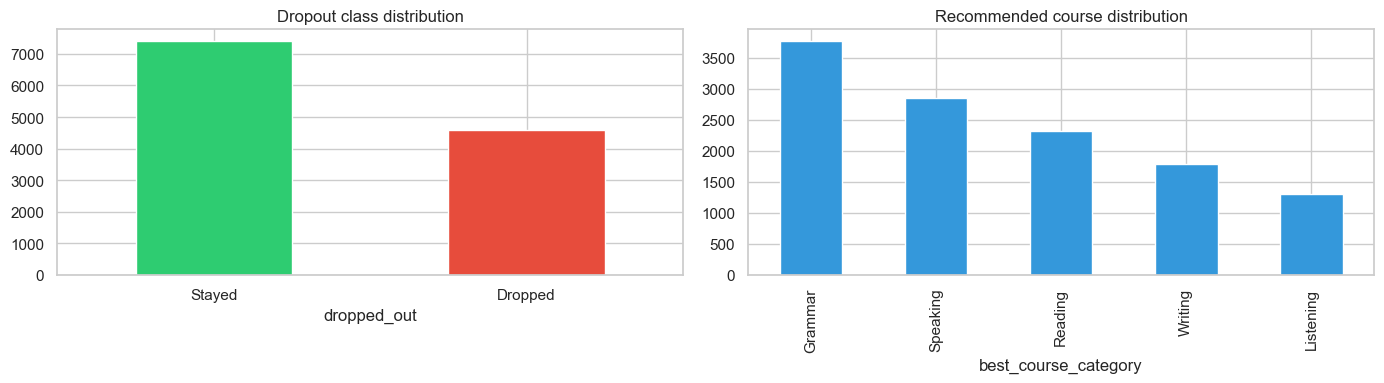

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['dropped_out'].value_counts().plot.bar(ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Dropout class distribution'); axes[0].set_xticklabels(['Stayed', 'Dropped'], rotation=0)
df['best_course_category'].value_counts().plot.bar(ax=axes[1], color='#3498db')
axes[1].set_title('Recommended course distribution')
plt.tight_layout(); plt.show()

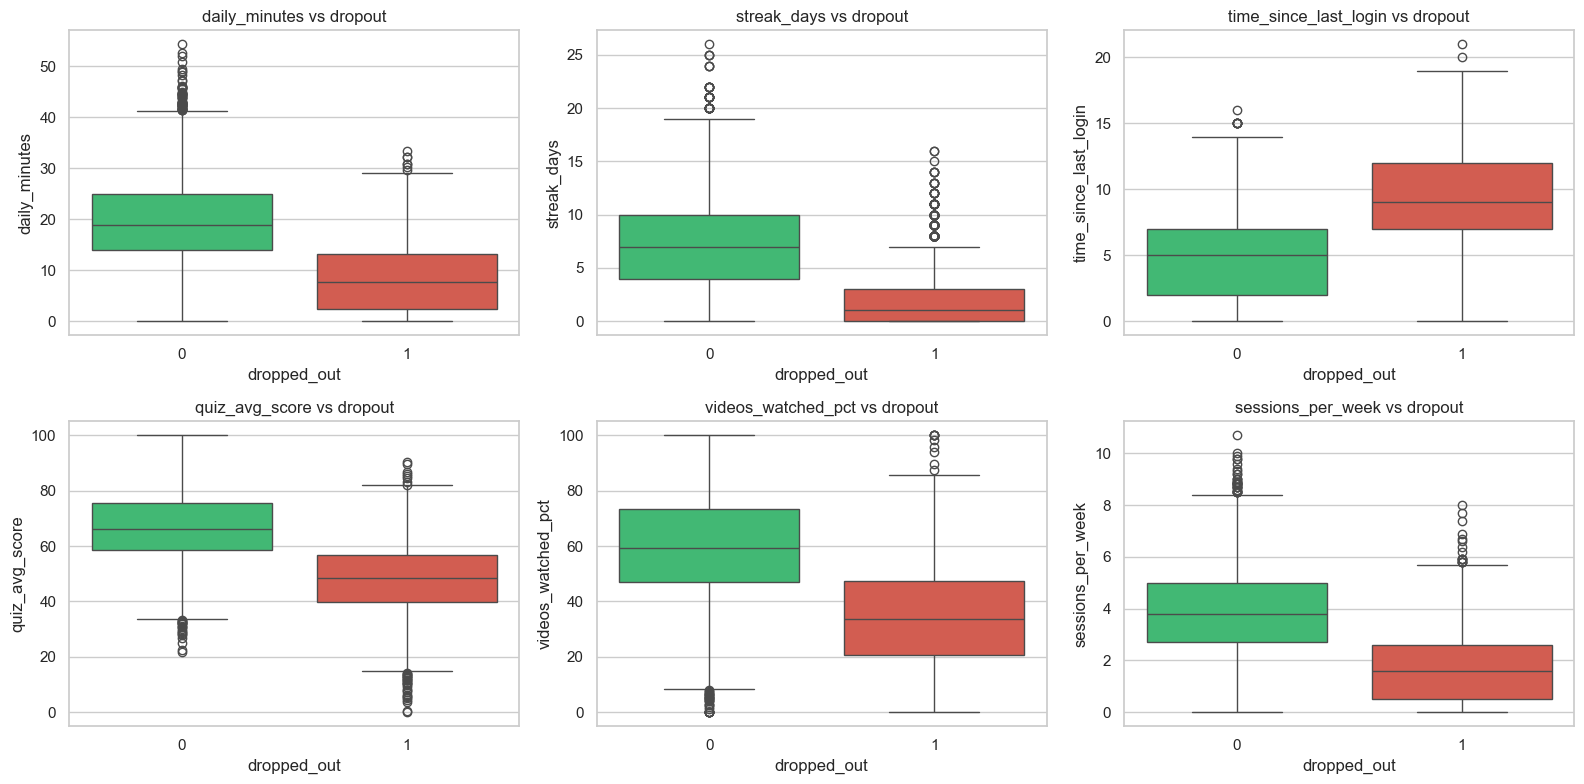

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
feats = ['daily_minutes', 'streak_days', 'time_since_last_login',
        'quiz_avg_score', 'videos_watched_pct', 'sessions_per_week']
for ax, f in zip(axes.flatten(), feats):
    sns.boxplot(data=df, x='dropped_out', y=f, ax=ax, palette=['#2ecc71', '#e74c3c'])
    ax.set_title(f'{f} vs dropout')
plt.tight_layout(); plt.show()

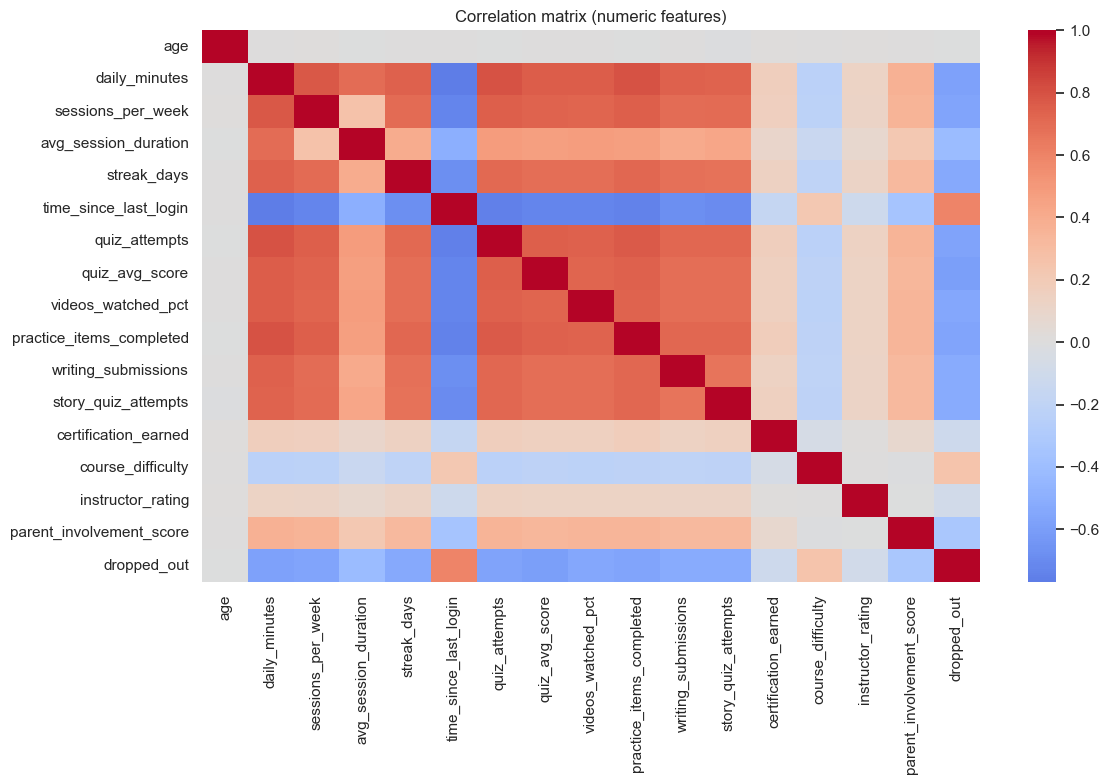

In [13]:
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation matrix (numeric features)')
plt.tight_layout(); plt.show()

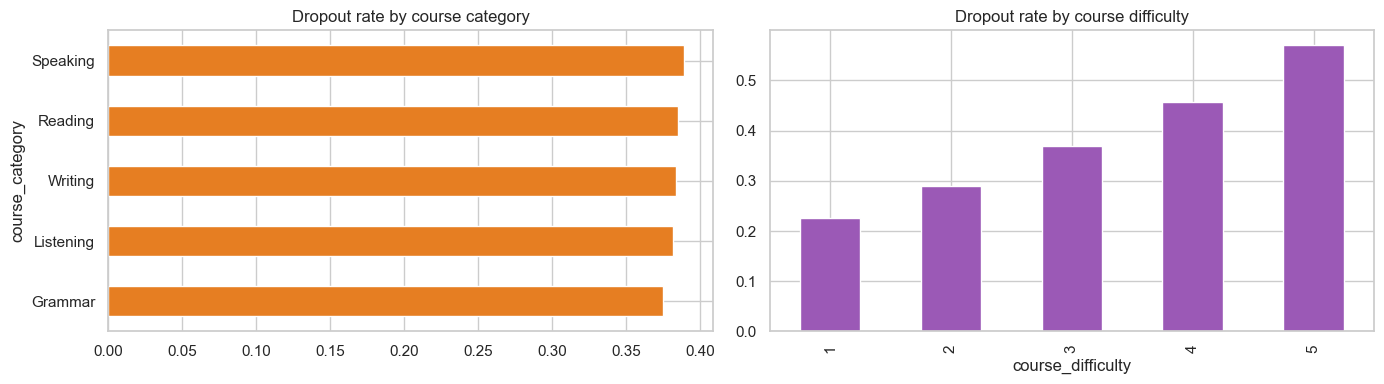

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
drop_by_cat = df.groupby('course_category')['dropped_out'].mean().sort_values()
drop_by_cat.plot.barh(ax=axes[0], color='#e67e22')
axes[0].set_title('Dropout rate by course category')
drop_by_diff = df.groupby('course_difficulty')['dropped_out'].mean()
drop_by_diff.plot.bar(ax=axes[1], color='#9b59b6')
axes[1].set_title('Dropout rate by course difficulty')
plt.tight_layout(); plt.show()

## 5. Feature engineering & preprocessing

In [15]:
FEATURES_NUM = [
    'age', 'daily_minutes', 'sessions_per_week', 'avg_session_duration',
    'streak_days', 'time_since_last_login', 'quiz_attempts', 'quiz_avg_score',
    'videos_watched_pct', 'practice_items_completed', 'writing_submissions',
    'story_quiz_attempts', 'certification_earned', 'course_difficulty',
    'instructor_rating', 'parent_involvement_score',
]
FEATURES_CAT = ['english_level', 'course_category', 'device_type', 'subscription_type']

X = df[FEATURES_NUM + FEATURES_CAT].copy()
y_dropout = df['dropped_out'].astype(int).values
y_recom = df['best_course_category'].values

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), FEATURES_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CAT),
])

X_train, X_test, yd_train, yd_test = train_test_split(
    X, y_dropout, test_size=0.2, random_state=RANDOM_STATE, stratify=y_dropout)
_, _, yr_train, yr_test = train_test_split(
    X, y_recom, test_size=0.2, random_state=RANDOM_STATE, stratify=y_recom)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (9604, 20), Test: (2401, 20)


## 6. Task A — Dropout prediction (binary classification)

### 6.1 Random Forest with `GridSearchCV`

In [16]:
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_grid = {
    'clf__n_estimators': [200, 400],
    'clf__max_depth': [None, 12, 20],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2],
    'clf__max_features': ['sqrt', 'log2'],
}

t0 = time.time()
rf_search = GridSearchCV(rf_pipe, rf_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
rf_search.fit(X_train, yd_train)
rf_train_time = time.time() - t0

print(f'RF best params: {rf_search.best_params_}')
print(f'RF best CV F1: {rf_search.best_score_:.4f}')
print(f'RF total grid-search time: {rf_train_time:.1f}s')

Fitting 3 folds for each of 48 candidates, totalling 144 fits
RF best params: {'clf__max_depth': 20, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 400}
RF best CV F1: 0.7702
RF total grid-search time: 34.4s


### 6.2 XGBoost with `GridSearchCV`

In [17]:
xgb_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', XGBClassifier(
        random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss',
        use_label_encoder=False, tree_method='hist')),
])

xgb_grid = {
    'clf__n_estimators': [200, 400],
    'clf__max_depth': [4, 6, 8],
    'clf__learning_rate': [0.05, 0.1],
    'clf__subsample': [0.8, 1.0],
    'clf__colsample_bytree': [0.8, 1.0],
    'clf__gamma': [0, 0.2],
}

t0 = time.time()
xgb_search = GridSearchCV(xgb_pipe, xgb_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
xgb_search.fit(X_train, yd_train)
xgb_train_time = time.time() - t0

print(f'XGB best params: {xgb_search.best_params_}')
print(f'XGB best CV F1: {xgb_search.best_score_:.4f}')
print(f'XGB total grid-search time: {xgb_train_time:.1f}s')

Fitting 3 folds for each of 96 candidates, totalling 288 fits
XGB best params: {'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 200, 'clf__subsample': 1.0}
XGB best CV F1: 0.7736
XGB total grid-search time: 19.2s


### 6.3 Live comparison — Random Forest vs XGBoost

In [18]:
def evaluate(model, X_te, y_te, name):
    t0 = time.time()
    y_pred = model.predict(X_te)
    inf_time = (time.time() - t0) * 1000  # ms
    y_proba = model.predict_proba(X_te)[:, 1]
    return {
        'model': name,
        'accuracy': accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred),
        'recall': recall_score(y_te, y_pred),
        'f1': f1_score(y_te, y_pred),
        'roc_auc': roc_auc_score(y_te, y_proba),
        'inference_ms': inf_time,
        '_y_pred': y_pred,
        '_y_proba': y_proba,
    }

rf_res = evaluate(rf_search.best_estimator_, X_test, yd_test, 'Random Forest')
xgb_res = evaluate(xgb_search.best_estimator_, X_test, yd_test, 'XGBoost')

comparison = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in (rf_res, xgb_res)
])
comparison['train_time_s'] = [rf_train_time, xgb_train_time]
comparison

,model,accuracy,precision,recall,f1,roc_auc,inference_ms,train_time_s
0,Random Forest,0.821324,0.784884,0.734494,0.758853,0.907810,79.048872,34.448229
1,XGBoost,0.827155,0.791667,0.744287,0.767246,0.909934,5.543709,19.221016


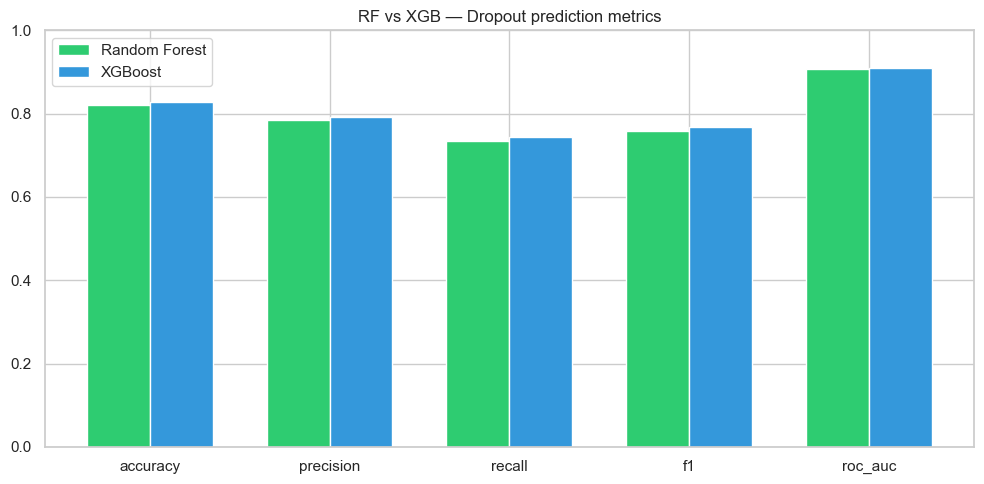

In [19]:
# Side-by-side metrics bar chart
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metrics)); width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, [rf_res[m] for m in metrics], width, label='Random Forest', color='#2ecc71')
ax.bar(x + width/2, [xgb_res[m] for m in metrics], width, label='XGBoost', color='#3498db')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1); ax.set_title('RF vs XGB — Dropout prediction metrics')
ax.legend(); plt.tight_layout(); plt.show()

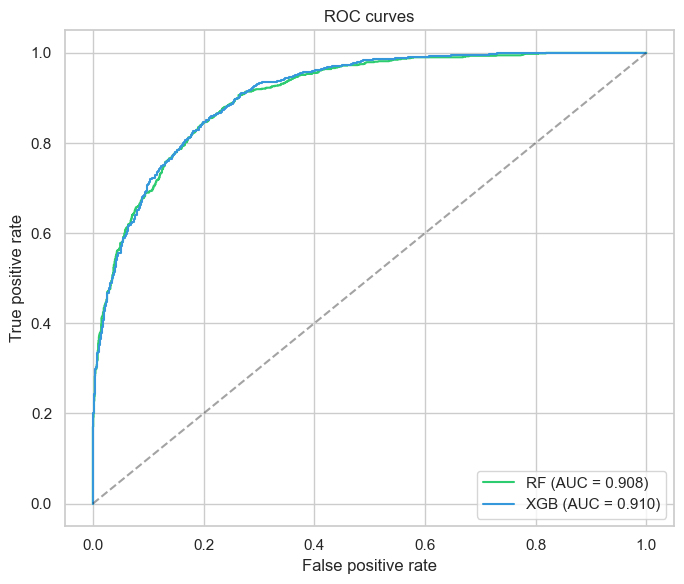

In [20]:
# ROC curves
fpr_rf, tpr_rf, _ = roc_curve(yd_test, rf_res['_y_proba'])
fpr_xgb, tpr_xgb, _ = roc_curve(yd_test, xgb_res['_y_proba'])
plt.figure(figsize=(7, 6))
plt.plot(fpr_rf, tpr_rf, label=f'RF (AUC = {rf_res["roc_auc"]:.3f})', color='#2ecc71')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGB (AUC = {xgb_res["roc_auc"]:.3f})', color='#3498db')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('ROC curves'); plt.legend(); plt.tight_layout(); plt.show()

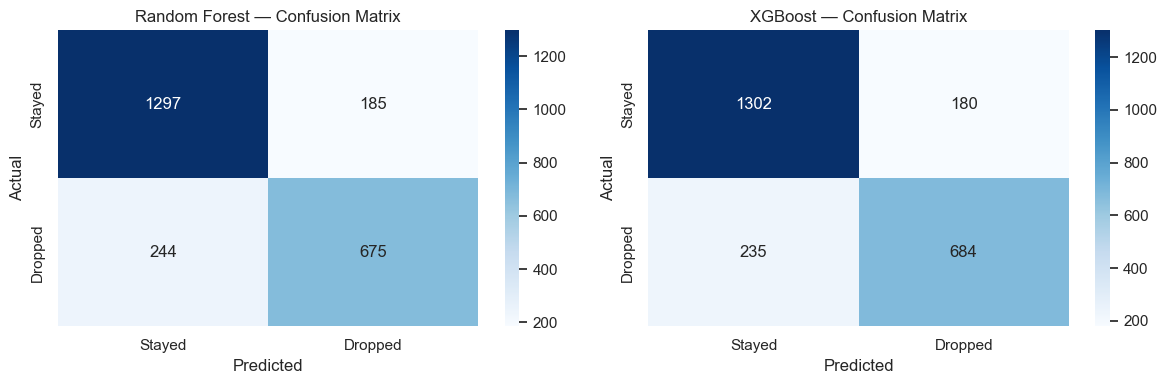

In [21]:
# Confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, res in zip(axes, [rf_res, xgb_res]):
    cm = confusion_matrix(yd_test, res['_y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Dropped'], yticklabels=['Stayed', 'Dropped'])
    ax.set_title(f"{res['model']} — Confusion Matrix")
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

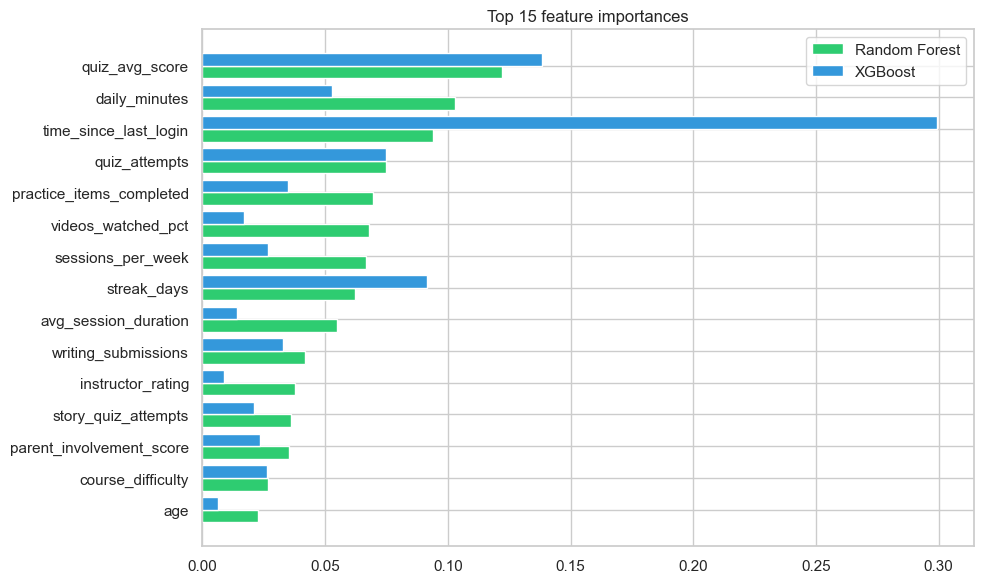

In [22]:
# Feature importances side-by-side
feat_names = (FEATURES_NUM
    + list(rf_search.best_estimator_.named_steps['prep']
                    .named_transformers_['cat'].get_feature_names_out(FEATURES_CAT)))
rf_imp = rf_search.best_estimator_.named_steps['clf'].feature_importances_
xgb_imp = xgb_search.best_estimator_.named_steps['clf'].feature_importances_

imp_df = pd.DataFrame({'feature': feat_names, 'RF': rf_imp, 'XGB': xgb_imp})
imp_df = imp_df.sort_values('RF', ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(imp_df))
ax.barh(y - 0.2, imp_df['RF'], 0.4, label='Random Forest', color='#2ecc71')
ax.barh(y + 0.2, imp_df['XGB'], 0.4, label='XGBoost', color='#3498db')
ax.set_yticks(y); ax.set_yticklabels(imp_df['feature'])
ax.set_title('Top 15 feature importances'); ax.legend()
plt.tight_layout(); plt.show()

## 7. Task B — Course recommendation (multi-class)

In [23]:
le = LabelEncoder()
yr_train_enc = le.fit_transform(yr_train)
yr_test_enc = le.transform(yr_test)

rf_rec = Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(
    n_estimators=400, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1))])
xgb_rec = Pipeline([('prep', preprocessor), ('clf', XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.1,
    objective='multi:softprob', num_class=len(le.classes_),
    random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist'))])

rf_rec.fit(X_train, yr_train_enc)
xgb_rec.fit(X_train, yr_train_enc)

rec_results = []
for name, model in [('Random Forest', rf_rec), ('XGBoost', xgb_rec)]:
    y_pred = model.predict(X_test)
    rec_results.append({
        'model': name,
        'accuracy': accuracy_score(yr_test_enc, y_pred),
        'f1_weighted': f1_score(yr_test_enc, y_pred, average='weighted'),
    })
pd.DataFrame(rec_results)

,model,accuracy,f1_weighted
0,Random Forest,0.330279,0.222516
1,XGBoost,0.283215,0.245296


## 8. Persist models and metrics for the FastAPI backend

In [24]:
joblib.dump(rf_search.best_estimator_, MODELS_DIR / 'rf_dropout.pkl')
joblib.dump(xgb_search.best_estimator_, MODELS_DIR / 'xgb_dropout.pkl')
joblib.dump(rf_rec, MODELS_DIR / 'rf_recommender.pkl')
joblib.dump(xgb_rec, MODELS_DIR / 'xgb_recommender.pkl')
joblib.dump(le, MODELS_DIR / 'recommender_label_encoder.pkl')

metrics_payload = {
    'dropout': {
        'random_forest': {
            'best_params': rf_search.best_params_,
            'accuracy': rf_res['accuracy'], 'precision': rf_res['precision'],
            'recall': rf_res['recall'], 'f1': rf_res['f1'],
            'roc_auc': rf_res['roc_auc'], 'train_time_s': rf_train_time,
            'inference_ms': rf_res['inference_ms'],
        },
        'xgboost': {
            'best_params': xgb_search.best_params_,
            'accuracy': xgb_res['accuracy'], 'precision': xgb_res['precision'],
            'recall': xgb_res['recall'], 'f1': xgb_res['f1'],
            'roc_auc': xgb_res['roc_auc'], 'train_time_s': xgb_train_time,
            'inference_ms': xgb_res['inference_ms'],
        },
        'roc_curves': {
            'rf': {'fpr': fpr_rf.tolist(), 'tpr': tpr_rf.tolist()},
            'xgb': {'fpr': fpr_xgb.tolist(), 'tpr': tpr_xgb.tolist()},
        },
        'confusion_matrices': {
            'rf': confusion_matrix(yd_test, rf_res['_y_pred']).tolist(),
            'xgb': confusion_matrix(yd_test, xgb_res['_y_pred']).tolist(),
        },
        'feature_importances': {
            'features': feat_names,
            'rf': rf_imp.tolist(),
            'xgb': xgb_imp.tolist(),
        },
    },
    'recommendation': rec_results,
    'class_labels': le.classes_.tolist(),
}

with open(MODELS_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_payload, f, indent=2, default=float)

print('Saved models + metrics.json')

Saved models + metrics.json
